Downloading/Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Starting Experiments...

EXPERIMENT SUMMARY TABLE
          Config Output Dim  Params  Time (s)  Accuracy
Valid | Stride 1      26x26   54410     41.93    0.9652
Same  | Stride 1      28x28   63050     41.66    0.9587
Valid | Stride 2      13x13   11850      9.30    0.9456
Same  | Stride 2      14x14   16010      8.97    0.9425


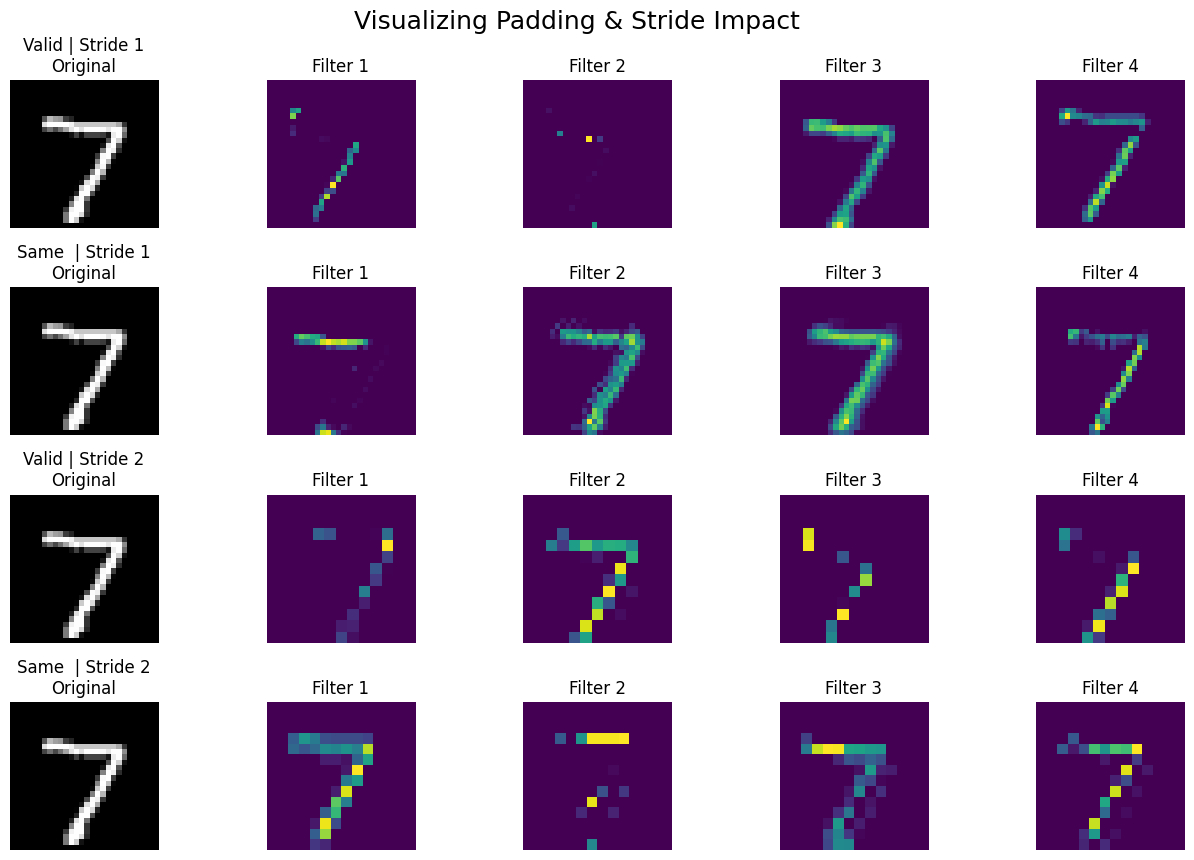

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

def run_experiments():
    """Main function to load data, iterate through CNN configs, and plot results."""

    # ---------------------------------------------------------
    # 1. LOAD AND PREPROCESS DATA
    # ---------------------------------------------------------
    print("Downloading/Loading MNIST dataset...")
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

    # Reshape to include the channel dimension (grayscale = 1) and normalize to [0, 1]
    x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
    x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

    # One-hot encode the target labels (0-9)
    y_train = keras.utils.to_categorical(y_train, 10)
    y_test = keras.utils.to_categorical(y_test, 10)

    # ---------------------------------------------------------
    # 2. DEFINE EXPERIMENT CONFIGURATIONS
    # ---------------------------------------------------------
    # We test four combinations to see how spatial downsampling and
    # boundary handling affect the network's geometry.
    configs = [
        {"padding": "valid", "stride": 1, "name": "Valid | Stride 1"},
        {"padding": "same",  "stride": 1, "name": "Same  | Stride 1"},
        {"padding": "valid", "stride": 2, "name": "Valid | Stride 2"},
        {"padding": "same",  "stride": 2, "name": "Same  | Stride 2"}
    ]

    results = []
    feature_maps_to_plot = []

    # Isolate a single test image to visualize the filter activations
    sample_digit = x_test[0:1]

    print("\nStarting Experiments...")
    for config in configs:
        # --- Build Model Architecture ---
        inputs = layers.Input(shape=(28, 28, 1))

        # Target Convolutional Layer where we apply our hyperparameter tests
        conv_layer = layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            padding=config['padding'],
            strides=config['stride'],
            activation='relu',
            name='target_conv'
        )(inputs)

        # Create an intermediate model specifically to extract the visual feature maps
        intermediate_model = keras.Model(inputs=inputs, outputs=conv_layer)

        # Complete the model for actual training
        x = layers.MaxPooling2D((2, 2))(conv_layer)
        x = layers.Flatten()(x)
        outputs = layers.Dense(10, activation='softmax')(x)
        model = keras.Model(inputs=inputs, outputs=outputs)

        # --- Extract Geometry and Metrics ---
        # Predict on the sample digit to get the spatial dimensions of the feature map
        maps = intermediate_model.predict(sample_digit, verbose=0)
        out_shape = maps.shape[1:3]
        params = model.count_params()

        # --- Train and Benchmark ---
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        start = time.time()
        # Brief training (2 epochs) just to measure time and base accuracy
        model.fit(x_train, y_train, epochs=2, batch_size=256, verbose=0)
        train_time = round(time.time() - start, 2)

        _, acc = model.evaluate(x_test, y_test, verbose=0)

        # --- Store Results ---
        results.append({
            "Config": config['name'],
            "Output Dim": f"{out_shape[0]}x{out_shape[1]}",
            "Params": params,
            "Time (s)": train_time,
            "Accuracy": round(acc, 4)
        })
        feature_maps_to_plot.append((maps, config['name']))

    # ---------------------------------------------------------
    # 3. CONSOLE SUMMARY OUTPUT
    # ---------------------------------------------------------
    print("\n" + "="*60)
    print("EXPERIMENT SUMMARY TABLE")
    print("="*60)
    # Pandas provides a clean, readable ASCII table for the console
    print(pd.DataFrame(results).to_string(index=False))

    # ---------------------------------------------------------
    # 4. MATPLOTLIB VISUALIZATION DASHBOARD
    # ---------------------------------------------------------
    fig, axes = plt.subplots(4, 5, figsize=(16, 10))
    plt.subplots_adjust(hspace=0.4)

    for i, (maps, name) in enumerate(feature_maps_to_plot):
        # Column 0: Show the Original Image
        axes[i, 0].imshow(sample_digit[0, :, :, 0], cmap='gray')
        axes[i, 0].set_title(f"{name}\nOriginal")
        axes[i, 0].axis('off')

        # Columns 1-4: Show the first 4 filter activations
        for j in range(1, 5):
            axes[i, j].imshow(maps[0, :, :, j], cmap='viridis')
            axes[i, j].set_title(f"Filter {j}")
            axes[i, j].axis('off')

    plt.suptitle("Visualizing Padding & Stride Impact", fontsize=18, y=0.95)
    plt.show()

if __name__ == "__main__":
    run_experiments()